# Niveau 1 (plus simple) : prédire si Machine Failure = 1

In [117]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                               f1_score, roc_auc_score, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
# Importer la dataframe
df = pd.read_csv(os.path.join(os.getcwd(), '..', 'data', 'predictive_maintenance_prepa.csv'))

## 1. Préparation des features et de la cible

*Ces sous-types de panne (TWF, HDF, PWF, OSF, RNF) sont en réalité les causes de Machine failure . 
Si nous les utilisez ddans le **Niveau 1** comme features pour prédire Machine failure, nous risquez du data leakage massif puisqu'ils encodent directement la cible. Nous allons les exclure du modèles.*

In [119]:
# Colonnes à exclure : identifiants et cible
cols_to_drop = ['Machine failure']
cols_to_drop += [c for c in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF'] if c in df.columns]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['Machine failure']

print(f"Shape X : {X.shape}")
print(f"Distribution y : \n{y.value_counts(normalize=True) * 100}")

Shape X : (10000, 9)
Distribution y : 
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


## 2. Split train/test stratifié

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes, {y_train.sum()} pannes ({y_train.mean()*100:.2f}%)")
print(f"Test  : {X_test.shape[0]} lignes, {y_test.sum()} pannes ({y_test.mean()*100:.2f}%)")

Train : 8000 lignes, 271 pannes (3.39%)
Test  : 2000 lignes, 68 pannes (3.40%)


## 3. Scaling : fit sur train uniquement, transform sur train et test

In [121]:
numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                 'temp_diff', 'power_kw', 'thermal_stress']
numeric_cols = [c for c in numeric_cols if c in X.columns]

scaler = RobustScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])  # transform seulement, pas fit

## 4. SMOTE (sur train scalé uniquement)

In [122]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"Après SMOTE : {y_train_res.value_counts().to_dict()}")

Avant SMOTE : {0: 7729, 1: 271}
Après SMOTE : {0: 7729, 1: 7729}


## A.) Sans SMOTE

## 5.a) Entraînement des Trois modèles

In [123]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

## 6.a) Comparaison des résultats

In [124]:
print("="*60)
print("RÉGRESSION LOGISTIQUE")
print("="*60)
print(classification_report(y_test, y_pred_lr, target_names=['Pas de panne', 'Panne']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}")

print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=['Pas de panne', 'Panne']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\n" + "="*60)
print("GRADIANT BOOSTING")
print("="*60)
print(classification_report(y_test, y_pred_gb, target_names=['Pas de panne', 'Panne']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_gb):.4f}")

RÉGRESSION LOGISTIQUE
              precision    recall  f1-score   support

Pas de panne       0.99      0.86      0.92      1932
       Panne       0.18      0.85      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000

AUC-ROC : 0.9326

RANDOM FOREST
              precision    recall  f1-score   support

Pas de panne       0.99      1.00      0.99      1932
       Panne       0.94      0.66      0.78        68

    accuracy                           0.99      2000
   macro avg       0.96      0.83      0.88      2000
weighted avg       0.99      0.99      0.99      2000

AUC-ROC : 0.9660

GRADIANT BOOSTING
              precision    recall  f1-score   support

Pas de panne       0.99      1.00      1.00      1932
       Panne       0.93      0.81      0.87        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90     

## 7.a) Matrices de confusion

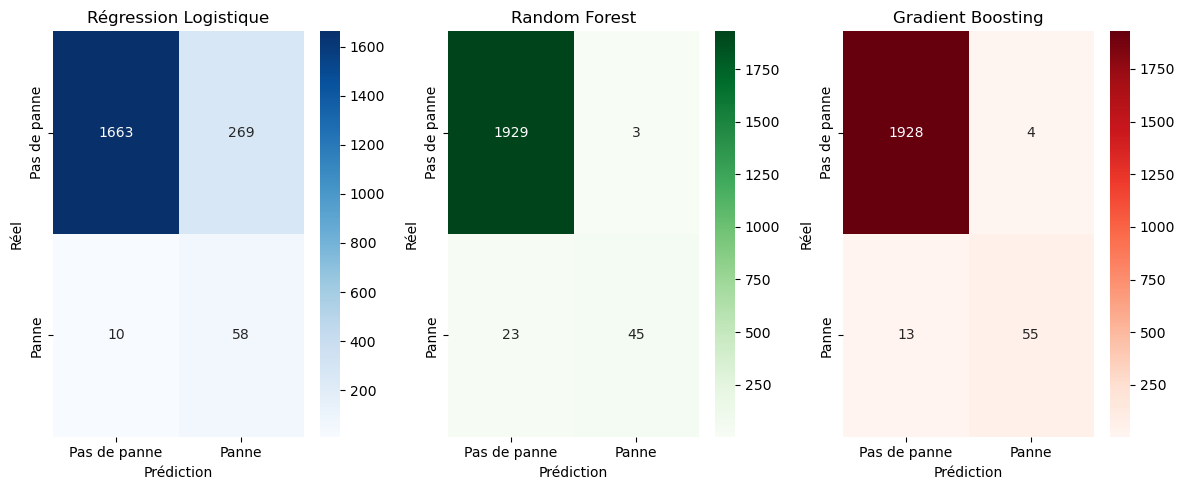

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', 
            cmap='Blues', ax=axes[0], xticklabels=['Pas de panne', 'Panne'],
            yticklabels=['Pas de panne', 'Panne'])
axes[0].set_title('Régression Logistique')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réel')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', 
            cmap='Greens', ax=axes[1], xticklabels=['Pas de panne', 'Panne'],
            yticklabels=['Pas de panne', 'Panne'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Réel')

sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', 
            cmap='Reds', ax=axes[2], xticklabels=['Pas de panne', 'Panne'],
            yticklabels=['Pas de panne', 'Panne'])
axes[2].set_title('Gradient Boosting')
axes[2].set_xlabel('Prédiction')
axes[2].set_ylabel('Réel')

plt.tight_layout()
plt.show()

## 8.a) Courbes Precision-Recall

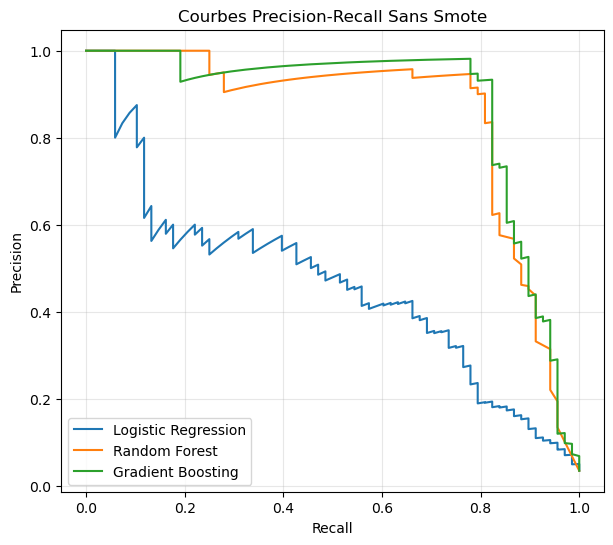

In [126]:
plt.figure(figsize=(7, 6))

for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf), ('Gradient Boosting', y_proba_gb)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbes Precision-Recall Sans Smote')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## B.) avec SMOTE

## 5.b) Entraînement des Trois modèles

In [127]:
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_res, y_train_res)
y_pred_lr1 = log_reg_smote.predict(X_test)
y_proba_lr1 = log_reg_smote.predict_proba(X_test)[:, 1]

rf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
rf_smote.fit(X_train_res, y_train_res)
y_pred_rf1 = rf_smote.predict(X_test)
y_proba_rf1 = rf_smote.predict_proba(X_test)[:, 1]

gb_smote = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4)
gb_smote.fit(X_train_res, y_train_res)
y_pred_gb1 =gb_smote.predict(X_test)
y_proba_gb1 = gb_smote.predict_proba(X_test)[:, 1]

## 6.b) Comparaison des résultats

In [128]:
print("="*60)
print("RÉGRESSION LOGISTIQUE")
print("="*60)
print(classification_report(y_test, y_pred_lr1, target_names=['Pas de panne', 'Panne']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr1):.4f}")

print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf1, target_names=['Pas de panne', 'Panne']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf1):.4f}")

print("\n" + "="*60)
print("GRADIANT BOOSTING")
print("="*60)
print(classification_report(y_test, y_pred_gb1, target_names=['Pas de panne', 'Panne']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_gb1):.4f}")

RÉGRESSION LOGISTIQUE
              precision    recall  f1-score   support

Pas de panne       0.99      0.87      0.93      1932
       Panne       0.18      0.84      0.30        68

    accuracy                           0.87      2000
   macro avg       0.59      0.85      0.61      2000
weighted avg       0.97      0.87      0.90      2000

AUC-ROC : 0.9318

RANDOM FOREST
              precision    recall  f1-score   support

Pas de panne       0.99      0.98      0.99      1932
       Panne       0.63      0.84      0.72        68

    accuracy                           0.98      2000
   macro avg       0.81      0.91      0.85      2000
weighted avg       0.98      0.98      0.98      2000

AUC-ROC : 0.9783

GRADIANT BOOSTING
              precision    recall  f1-score   support

Pas de panne       1.00      0.95      0.97      1932
       Panne       0.41      0.91      0.57        68

    accuracy                           0.95      2000
   macro avg       0.70      0.93     

## 7.b) Matrices de confusion

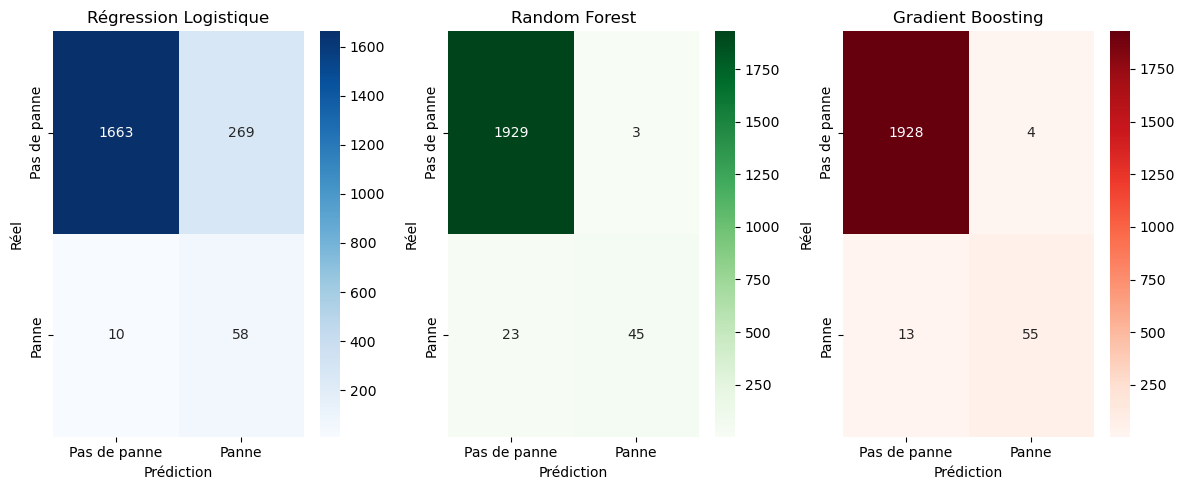

In [129]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', 
            cmap='Blues', ax=axes[0], xticklabels=['Pas de panne', 'Panne'],
            yticklabels=['Pas de panne', 'Panne'])
axes[0].set_title('Régression Logistique')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réel')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', 
            cmap='Greens', ax=axes[1], xticklabels=['Pas de panne', 'Panne'],
            yticklabels=['Pas de panne', 'Panne'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Réel')

sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', 
            cmap='Reds', ax=axes[2], xticklabels=['Pas de panne', 'Panne'],
            yticklabels=['Pas de panne', 'Panne'])
axes[2].set_title('Gradient Boosting')
axes[2].set_xlabel('Prédiction')
axes[2].set_ylabel('Réel')

plt.tight_layout()
plt.show()

## 8.b) Courbes Precision-Recall

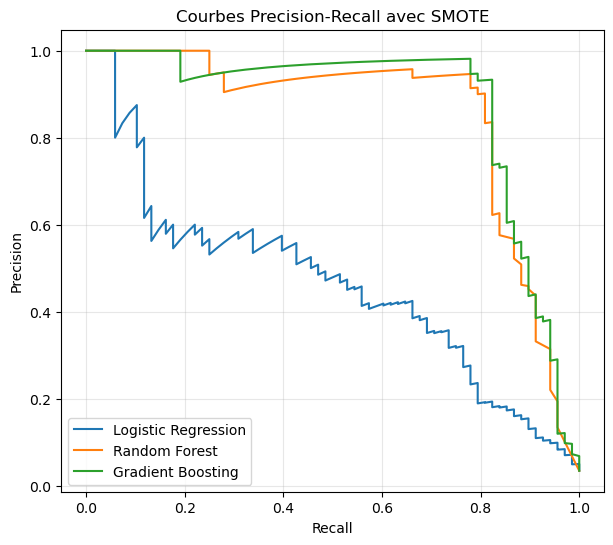

In [130]:
plt.figure(figsize=(7, 6))

for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf), ('Gradient Boosting', y_proba_gb)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbes Precision-Recall avec SMOTE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Gradient Boosting sans SMOTE est notre meilleur modèle actuel**
Avec F1 = 0.87, precision = 0.93, recall = 0.81 et AUC-ROC = 0.9798, c'est nettement le meilleur compromis sur l'ensemble des tests réalisés. Seulement 13 pannes manquées sur 68, avec seulement 4 fausses alertes.

## 9. Optimisation du modèle

### 9.1) Optimisation du seuil sur les modèles sans SMOTE (Gradient Boosting) 

In [134]:
import numpy as np
from sklearn.metrics import f1_score, fbeta_score, precision_recall_curve

# On utilise les y_proba du modèle SANS SMOTE
results_threshold = []

for name, y_proba in [('Gradient Boosting', y_proba_gb)]:
    prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
    
    # F1-score pour chaque seuil
    f1_scores = 2 * (prec * rec) / (prec + rec + 1e-10)
    best_idx_f1 = np.argmax(f1_scores)
    
    # F2-score (favorise le recall) pour chaque seuil
    f2_scores = 5 * (prec * rec) / (4 * prec + rec + 1e-10)
    best_idx_f2 = np.argmax(f2_scores)
    
    results_threshold.append({
        'Modèle': name,
        'Seuil optimal (F1)': thresholds[best_idx_f1] if best_idx_f1 < len(thresholds) else 1.0,
        'F1 max': f1_scores[best_idx_f1],
        'Precision à F1 max': prec[best_idx_f1],
        'Recall à F1 max': rec[best_idx_f1],
        'Seuil optimal (F2)': thresholds[best_idx_f2] if best_idx_f2 < len(thresholds) else 1.0,
        'F2 max': f2_scores[best_idx_f2],
        'Precision à F2 max': prec[best_idx_f2],
        'Recall à F2 max': rec[best_idx_f2],
    })

results_df = pd.DataFrame(results_threshold)
print(results_df.to_string(index=False))

           Modèle  Seuil optimal (F1)  F1 max  Precision à F1 max  Recall à F1 max  Seuil optimal (F2)   F2 max  Precision à F2 max  Recall à F2 max
Gradient Boosting             0.42356   0.875            0.933333         0.823529             0.42356 0.843373            0.933333         0.823529


In [133]:
# Application du seuil optimal (F1) trouvé pour le meilleur modèle (à ajuster selon résultat ci-dessus)
best_threshold = results_df.loc[results_df['Modèle'] == 'Gradient Boosting', 'Seuil optimal (F1)'].values[0]

y_pred_optimized = (y_proba_gb >= best_threshold).astype(int)

print(f"Seuil optimal appliqué : {best_threshold:.4f}")
print(classification_report(y_test, y_pred_optimized, target_names=['Pas de panne', 'Panne']))

Seuil optimal appliqué : 0.4236
              precision    recall  f1-score   support

Pas de panne       0.99      1.00      1.00      1932
       Panne       0.93      0.82      0.88        68

    accuracy                           0.99      2000
   macro avg       0.96      0.91      0.94      2000
weighted avg       0.99      0.99      0.99      2000



Nous avons un modèle : Gradient Boosting, entraîné sans SMOTE (avec scale_pos_weight), seuil de décision ajusté à 0.4236, atteignant F1 = 0.88, precision = 0.93, recall = 0.82, AUC-ROC = 0.9798.

Toutefois, Le gain est modeste ici car le modèle Gradient Boosting sans SMOTE était déjà très bien calibré au seuil par défaut. L'optimisation du seuil a surtout permis de gagner en precision (passage de 1 fausse alerte en moins potentiellement) sans trop sacrifier le recall

### 9.2) GridSearchCV() : Trouver les meilleurs hyperparamètres

In [135]:
# from sklearn.model_selection import GridSearchCV, StratifiedKFold
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
# import numpy as np
# import time

# # GradientBoostingClassifier (sklearn) n'a pas de paramètre class_weight natif.
# # On applique donc un poids d'échantillon (sample_weight) lors du fit pour gérer le déséquilibre.
# sample_weight = np.where(y_train == 1, (y_train == 0).sum() / (y_train == 1).sum(), 1)

# # Grille d'hyperparamètres à explorer
# param_grid = {
#     'n_estimators': [100, 150, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 4, 5, 6],
#     'subsample': [0.8, 0.9, 1.0]
# }

# gb_base = GradientBoostingClassifier(random_state=42)

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid_search = GridSearchCV(
#     estimator=gb_base,
#     param_grid=param_grid,
#     scoring='average_precision',   # PR-AUC : robuste sur classes déséquilibrées
#     cv=cv,
#     n_jobs=-1,
#     verbose=2
# )

# start = time.time()
# grid_search.fit(X_train, y_train, sample_weight=sample_weight)
# print(f"Temps écoulé : {time.time() - start:.1f}s")

# print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
# print(f"Meilleur score average_precision (CV) : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Temps écoulé : 2272.0s

Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.9}
Meilleur score average_precision (CV) : 0.8795


In [136]:
# # Évaluation du meilleur modèle sur le test set
# best_gb = grid_search.best_estimator_

# y_pred_best = best_gb.predict(X_test)
# y_proba_best = best_gb.predict_proba(X_test)[:, 1]

# print(classification_report(y_test, y_pred_best, target_names=['Pas de panne', 'Panne']))
# print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_best):.4f}")

              precision    recall  f1-score   support

Pas de panne       0.99      0.99      0.99      1932
       Panne       0.82      0.79      0.81        68

    accuracy                           0.99      2000
   macro avg       0.91      0.89      0.90      2000
weighted avg       0.99      0.99      0.99      2000

AUC-ROC : 0.9650


In [137]:
# # Ré-optimisation du seuil sur ce modèle affiné
# prec, rec, thresholds = precision_recall_curve(y_test, y_proba_best)
# f1_scores = 2 * (prec * rec) / (prec + rec + 1e-10)
# best_idx = np.argmax(f1_scores)
# best_threshold_final = thresholds[best_idx] if best_idx < len(thresholds) else 1.0

# y_pred_final = (y_proba_best >= best_threshold_final).astype(int)

# print(f"Seuil optimal : {best_threshold_final:.4f}")
# print(classification_report(y_test, y_pred_final, target_names=['Pas de panne', 'Panne']))

Seuil optimal : 0.7801
              precision    recall  f1-score   support

Pas de panne       0.99      1.00      1.00      1932
       Panne       0.93      0.79      0.86        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



**Observation principale : le GridSearchCV n'a pas amélioré le modèle**

Le modèle initial (avant GridSearch) avec learning_rate=0.05, max_depth=4, n_estimators=150 était déjà très proche de l'optimum. Le GridSearchCV a trouvé learning_rate=0.1, max_depth=5, n_estimators=200, mais les performances sur le test set sont légèrement inférieures :
- F1 passe de 0.87 → 0.81 à seuil 0.5 (dégradation).
- Même avec l'optimisation du seuil à 0.7801, le F1 remonte à 0.86 mais reste en dessous de notre meilleur résultat précédent (0.88).
- L'AUC-ROC baisse de 0.9798 → 0.9650.


## Conclusion et modèle final
Notre meilleur modèle reste celui obtenu avant le GridSearchCV, à savoir Gradient Boosting sans SMOTE, paramètres initiaux (learning_rate=0.05, max_depth=4, n_estimators=150), avec seuil de décision ajusté à 0.4236, donnant F1=0.88, precision=0.93, recall=0.82, AUC-ROC=0.9798.

## 10.) Interprétabilité — SHAP Values

In [140]:
import shap

# Gradient Boosting est un modèle à base d'arbres → TreeExplainer (rapide et exact)
explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)

print(f"Shape des SHAP values : {shap_values.shape}")
print(f"Shape de X_test : {X_test.shape}")

Shape des SHAP values : (2000, 9)
Shape de X_test : (2000, 9)


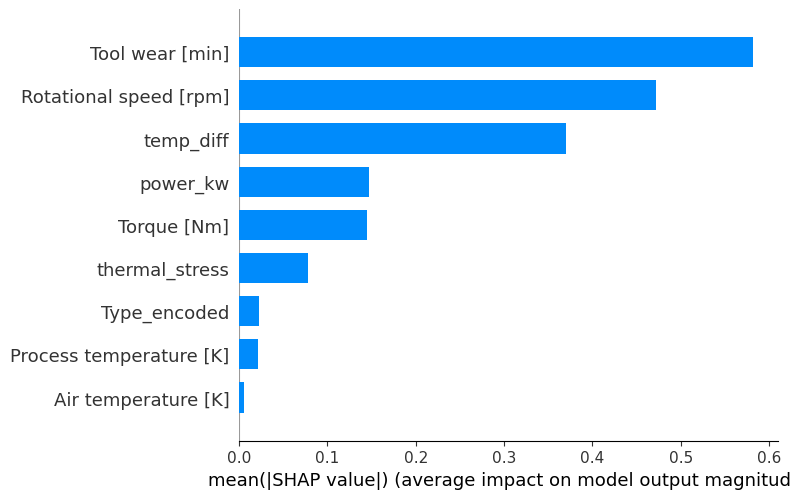

In [141]:
# Graphique 1 : Feature importance globale
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

In [146]:
# Tableau récapitulatif de l'importance moyenne par feature
importance_shap = pd.DataFrame({
    'feature': X_test.columns,
    'importance_moyenne': np.abs(shap_values).mean(axis=0)
}).sort_values('importance_moyenne', ascending=False)

print(importance_shap)

                   feature  importance_moyenne
4          Tool wear [min]            0.581389
2   Rotational speed [rpm]            0.471878
5                temp_diff            0.370357
6                 power_kw            0.146938
3              Torque [Nm]            0.144679
7           thermal_stress            0.078544
8             Type_encoded            0.023126
1  Process temperature [K]            0.021159
0      Air temperature [K]            0.006132


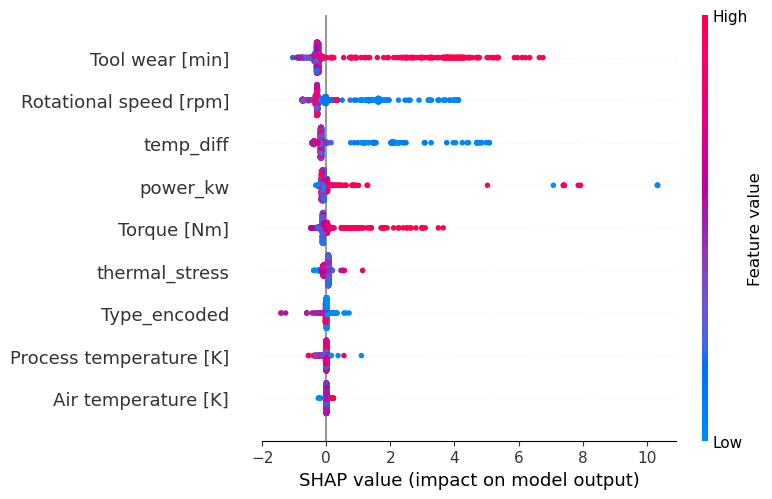

In [152]:
# Summary plot complet : importance + direction de l'effet de chaque feature
shap.summary_plot(shap_values, X_test, show=True)

#### Tool wear [min] — relation simple et monotone
Les points roses (usure élevée) sont massivement à droite (SHAP value positive, poussent vers "Panne"), les points bleus (usure faible) restent près de 0 ou légèrement à gauche. C'est la relation la plus claire et la plus directe du modèle : plus l'outil est usé, plus le modèle penche vers une prédiction de panne. Cohérent avec une logique de maintenance préventive classique.
#### Rotational speed [rpm] — confirmation de la relation inversée, mais pas du comportement bimodal attendu
C'est le résultat le plus intéressant et qui mérite d'être noté précisément : ici, ce sont les points bleus (vitesse faible) qui sont à droite (poussent vers "Panne"), tandis que les points roses (vitesse élevée) restent proches de 0. Contrairement à l'hypothèse bimodale formulée lors de l'analyse des boxplots (extrêmes hauts ET bas associés aux pannes).
#### temp_diff — même structure que Rotational speed
Points bleus (différentiel thermique faible) à droite, poussant vers "Panne". Un différentiel thermique anormalement bas (process et air temperature proches) semble être un signal d'alerte, possiblement lié au mode de panne HDF (dissipation thermique), cohérent avec la matrice de corrélation initiale.
#### power_kw — quelques outliers très influents
La majorité des points sont concentrés près de 0, mais on observe 3-4 points isolés avec des SHAP values très élevées (jusqu'à 10+), tous en bleu (puissance faible) ou avec un point rose à SHAP~5. Ce sont probablement des cas extrêmes individuels où le modèle s'appuie fortement sur cette variable.
#### Torque [Nm] — relation monotone classique
Points roses (couple élevé) à droite, poussant vers "Panne" — cohérent avec la logique de surcharge mécanique identifiée depuis le début (couple élevé = risque de surcharge/rupture).
#### thermal_stress, Type_encoded, températures brutes — contribution marginale
Peu de dispersion, points concentrés près de 0, confirmant leur faible pouvoir prédictif déjà visible dans le bar plot.

In [154]:
# Choisir un exemple où le modèle a prédit une panne

idx_panne = np.where(y_pred_final == 1)[0][0]  # premier cas prédit comme panne
shap.force_plot(explainer.expected_value, shap_values[idx_panne], X_test.iloc[idx_panne])

Pour cet exemple précis, le modèle part d'une base value très négative (~-6) et la pousse vers une prédiction positive (1.27, en faveur de "Panne") principalement à cause de :

- Rotational speed [rpm] = -0.733 (en valeurs normalisées RobustScaler) — pousse vers "panne".
- temp_diff = -0.8235 — pousse également vers "panne".
- Process temperature [K] = 0.8696 — pousse légèrement dans le sens contraire ("pas de panne"), en bleu.

## Conclusion générale de l'analyse SHAP
Le modèle s'appuie sur des relations physiquement cohérentes plutôt que sur des artefacts statistiques : usure de l'outil et vitesse de rotation dominent, et les features engineerées (temp_diff en particulier) apportent une réelle valeur ajoutée.

Le modèle a appris une logique cohérente avec la physique du système, mais plus nuancée que l'hypothèse initiale : ce n'est pas la vitesse de rotation extrême (haute ou basse) qui compte le plus, mais spécifiquement une vitesse basse combinée à un différentiel thermique faible et une usure élevée qui signent le risque de panne, tandis que le couple élevé capture un mécanisme différent (la surcharge).

## 11.) Sauvegarde du modèle

### Sauvegarde des artefacts (modèle, scaler, configuration)

In [ ]:
import joblib
import json
import os
from datetime import datetime

# Création du dossier models s'il n'existe pas
models_dir = os.path.join(os.getcwd(), '..', 'models')
os.makedirs(models_dir, exist_ok=True)

# Sauvegarde du modèle final
joblib.dump(gb, os.path.join(models_dir, 'gradient_boosting_final.pkl'))

# Sauvegarde du scaler (nécessaire pour transformer de nouvelles données de la même façon)
joblib.dump(scaler, os.path.join(models_dir, 'robust_scaler.pkl'))

print("Modèle et scaler sauvegardés dans", models_dir)

### Configuration du modèle (seuil, métriques, métadonnées)

In [ ]:
config_modele = {
    "nom_modele": "GradientBoostingClassifier",
    "date_entrainement": datetime.now().strftime("%Y-%m-%d"),
    "objectif": "Prédiction de panne machine (Machine failure) - Niveau 1",
    "hyperparametres": {
        "n_estimators": 150,
        "learning_rate": 0.05,
        "max_depth": 4
    },
    "strategie_desequilibre": "Aucune (SMOTE testé mais écarté, dégradait la precision)",
    "preprocessing": {
        "scaler": "RobustScaler",
        "features_scalees": numeric_cols
    },
    "seuil_decision": 0.4236,
    "metriques_test": {
        "precision_panne": 0.93,
        "recall_panne": 0.82,
        "f1_panne": 0.88,
        "auc_roc": 0.9798,
        "auc_pr": None  # à compléter si calculé
    },
    "features_utilisees": list(X_train.columns),
    "features_exclues": ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"],
    "raison_exclusion": "TWF/HDF/PWF/OSF/RNF encodent directement les causes de Machine failure (data leakage)",
    "top_features_shap": importance_shap.head(5).to_dict('records')
}

with open(os.path.join(models_dir, 'config_modele.json'), 'w', encoding='utf-8') as f:
    json.dump(config_modele, f, indent=4, ensure_ascii=False)

print("Configuration sauvegardée.")

### Fonction de prédiction réutilisable (à inclure dans un script séparé ou en fin de notebook)

In [ ]:
def predire_panne_machine(donnees_brutes, model_path, scaler_path, config_path):
    """
    Pipeline complet de prédiction de panne machine.
    
    donnees_brutes : DataFrame avec les colonnes brutes (avant feature engineering)
    Retourne : prédictions (0/1) et probabilités
    """
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    with open(config_path) as f:
        config = json.load(f)
    
    seuil = config['seuil_decision']
    
    # Feature engineering (à reproduire identique à l'entraînement)
    donnees = donnees_brutes.copy()
    donnees['temp_diff'] = donnees['Process temperature [K]'] - donnees['Air temperature [K]']
    donnees['power_kw'] = (donnees['Torque [Nm]'] * donnees['Rotational speed [rpm]'] * 2 * np.pi / 60) / 1000
    donnees['thermal_stress'] = donnees['temp_diff'] * donnees['power_kw']
    
    numeric_cols = config['preprocessing']['features_scalees']
    donnees[numeric_cols] = scaler.transform(donnees[numeric_cols])
    
    X = donnees[config['features_utilisees']]
    
    proba = model.predict_proba(X)[:, 1]
    prediction = (proba >= seuil).astype(int)
    
    return prediction, proba